In [137]:
import numpy as np 
import math
import matplotlib.pyplot as plt
import scipy.stats


In [138]:

# Stock price at n steps of the tree
def terminal_prices(s0, u, d, n):
    j = np.arange(n+1)
    S = s0 * (u ** j) * (d ** (n-j))
    return S

# Payoff function of the option 
def payoff(S, K, opt):
    if opt == "c":
        return np.maximum(S - K, 0)
    elif opt == "p":
        return np.maximum(K - S, 0)
    else:
        raise ValueError(f"opt must be 'c' or 'p', got {opt!r}")

# Option price for American and European options
class Option_Pricer:
    def __init__(self, s0, K, T, r, sigma, n, opt, style):
        self.s0 = s0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.n = n
        self.opt = opt
        self.style = style

    def opt_price(self, n):
        dt = self.T / n
        u = np.exp(self.sigma * np.sqrt(dt))
        d = 1/u
        s = payoff(terminal_prices(self.s0, u, d, n), self.K, self.opt) 
        p = (np.exp(self.r*dt) - d) / (u - d)
        disc = np.exp(-self.r*dt)
        if self.style == "european":
            for i in range(n):
                s = disc * (p * s[1:] + (1-p) * s[:-1])
            return s
        elif self.style == "american":
            for i in range(n):
                s = np.maximum(payoff(terminal_prices(self.s0, u, d, n-1-i), self.K, self.opt), (disc * (p * s[1:] + (1-p) * s[:-1])))
            return s
        else:
            raise ValueError(f"style must be 'european' or 'american', got {self.style!r}")
   
    # Black-Scholes model for Call and Put
    def Black_Scholes_Model(self):
        d1 = ((np.log(self.s0/self.K)) + ((self.r + ((self.sigma**2 / 2)))*self.T)) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        dist = scipy.stats.norm.cdf 
        if self.opt == "c":
            c = self.s0 * dist(d1) - self.K*np.exp(-self.r*self.T)*dist(d2)
            return c
        elif self.opt == "p":
            p = self.K*np.exp(-self.r*self.T)*dist(-d2)-self.s0*dist(-d1)
            return p
        else:
            raise ValueError(f"opt must be 'c' or 'p', got {self.opt!r}")

    # Building the Greeks
    def delta(self):
        h = 0.01
        a = Option_Pricer(self.s0 + h, self.K, self.T, self.r, self.sigma, self.n, self.opt, self.style)
        b = Option_Pricer(self.s0 - h, self.K, self.T, self.r, self.sigma, self.n, self.opt, self.style)
        return (float(a.opt_price(self.n)[0]) - float(b.opt_price(self.n)[0])) / (2*h)

    def vega(self):
        h = 0.001
        a = Option_Pricer(self.s0, self.K, self.T, self.r, self.sigma + h, self.n, self.opt, self.style)
        b = Option_Pricer(self.s0, self.K, self.T, self.r, self.sigma - h, self.n, self.opt, self.style)
        return ((float(a.opt_price(self.n)[0]) - float(b.opt_price(self.n)[0])) / (2*h))/ 100
    
    def theta(self):
        h = 1/365
        a = Option_Pricer(self.s0, self.K, self.T + h, self.r, self.sigma, self.n, self.opt, self.style)
        b = Option_Pricer(self.s0, self.K, self.T - h, self.r, self.sigma, self.n, self.opt, self.style)
        return (-((float(a.opt_price(self.n)[0]) - float(b.opt_price(self.n)[0])) / (2*h))) / 365

    def gamma(self):
        h = 2
        a = Option_Pricer(self.s0 + h, self.K, self.T, self.r, self.sigma, self.n, self.opt, self.style)
        b = Option_Pricer(self.s0, self.K, self.T, self.r, self.sigma, self.n, self.opt, self.style)
        c = Option_Pricer(self.s0 - h, self.K, self.T, self.r, self.sigma, self.n, self.opt, self.style)
        return (((float(a.opt_price(self.n)[0]) - 2*float(b.opt_price(self.n)[0]) + float(c.opt_price(self.n)[0])) / h**2)) 

# Put-call parity for bug catching
def parity(s0, K, T, r, sigma, n, style):
    c = Option_Pricer(s0, K, T, r, sigma, n, "c", style)
    p = Option_Pricer(s0, K, T, r, sigma, n, "p", style)
    return np.isclose((s0 - K*np.exp(-r*T)), (float(c.opt_price(n)[0]) - float(p.opt_price(n)[0])))

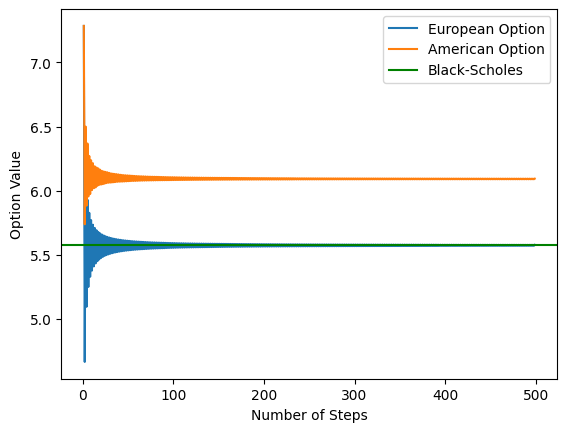

In [139]:
x = []
y1 = []
y2 = []

for n in range(1, 500):
    x.append(n)
    eu = Option_Pricer(100, 100, 1, 0.05, 0.2, n, "p", "european")
    am = Option_Pricer(100, 100, 1, 0.05, 0.2, n, "p", "american")
    e = float(eu.opt_price(n)[0])
    y1.append(e)
    m = float(am.opt_price(n)[0])
    y2.append(m)
bs = eu.Black_Scholes_Model()


plt.plot(x, y1, label="European Option")
plt.plot(x, y2, label="American Option")
plt.axhline(bs, label="Black-Scholes", color="Green")
plt.xlabel("Number of Steps")
plt.ylabel("Option Value")
plt.legend()
plt.show()



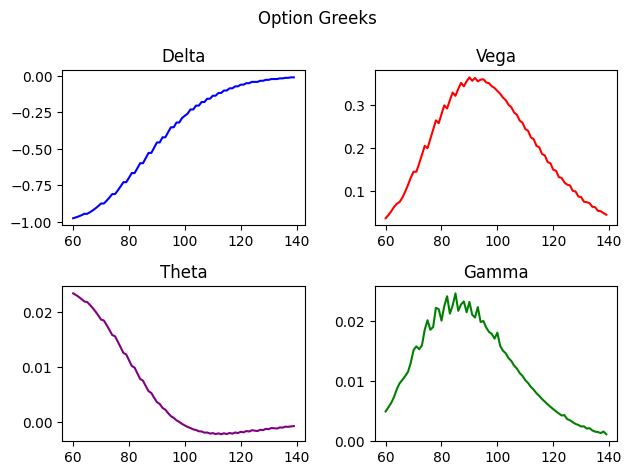

In [140]:
x = []
delta = []
vega = []
theta = []
gamma = []
for s0 in range(60, 140):
    x.append(s0)
    put = Option_Pricer(s0, 100, 1, 0.1, 0.2, 500, "p", "european")
    delta.append((put.delta()))
    vega.append((put.vega()))
    theta.append((put.theta()))
    gamma.append((put.gamma()))

fig, ax = plt.subplots(2, 2)

fig.suptitle("Option Greeks")
ax[0, 0].set_title("Delta")
ax[0, 0].plot(x, delta, color="Blue")
ax[0, 1].set_title("Vega")
ax[0, 1].plot(x, vega, color="Red")
ax[1, 0].set_title("Theta")
ax[1, 0].plot(x, theta, color="Purple")
ax[1, 1].set_title("Gamma")
ax[1, 1].plot(x, gamma, color="Green")
fig.tight_layout()
plt.show()

**Breaking the model by inputting imposible parameters**

In [141]:
!NOTE: Breaking the model by inputting an imposible p (p > 1)
# Stock price at n steps of the tree
def terminal_prices(s0, u, d, n):
    j = np.arange(n+1)
    S = s0 * (u ** j) * (d ** (n-j))
    return S

# Payoff function of the option 
def payoff(S, K, opt):
    if opt == "c":
        return np.maximum(S - K, 0)
    elif opt == "p":
        return np.maximum(K - S, 0)
    else:
        raise ValueError(f"opt must be 'c' or 'p', got {opt!r}")

# Option price for American and European options
class Option_Pricer:
    def __init__(self, s0, K, T, r, sigma, n, opt, style):
        self.s0 = s0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.n = n
        self.opt = opt
        self.style = style


    def opt_price(self, n):
        dt = self.T / n
        u = np.exp(self.sigma * np.sqrt(dt))
        d = 1/u
        s = payoff(terminal_prices(self.s0, u, d, n), self.K, self.opt) 
        p = (np.exp(self.r*dt) - d) / (u - d)
        if 0 > p or p > 1:
            raise ValueError(f"p must fall between 0 and 1: {p:2f}")        
        disc = np.exp(-self.r*dt)
        if self.style == "european":
            for i in range(n):
                s = disc * (p * s[1:] + (1-p) * s[:-1])
            return s
        elif self.style == "american":
            for i in range(n):
                s = np.maximum(payoff(terminal_prices(self.s0, u, d, n-1-i), self.K, self.opt), (disc * (p * s[1:] + (1-p) * s[:-1])))
            return s
        else:
            raise ValueError(f"style must be 'european' or 'american', got {self.style!r}")
    # Black-Scholes model for Call and Put
    def Black_Scholes_Model(self):
        d1 = ((np.log(self.s0/self.K)) + ((self.r + ((self.sigma**2 / 2)))*self.T)) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        dist = scipy.stats.norm.cdf 
        if self.opt == "c":
            c = self.s0 * dist(d1) - self.K*np.exp(-self.r*self.T)*dist(d2)
            return c
        elif self.opt == "p":
            p = self.K*np.exp(-self.r*self.T)*dist(-d2)-self.s0*dist(-d1)
            return p
        else:
            raise ValueError(f"opt must be 'c' or 'p', got {self.opt!r}")

def parity(s0, K, T, r, sigma, n, opt, style):
    c = Option_Pricer(s0, K, T, r, sigma, n, opt, style)
    p = Option_Pricer(s0, K, T, r, sigma, n, opt, style)
    return np.isclose((s0 - K*np.exp(-r*T)), (float(c.opt_price(n)[0]) - float(p.opt_price(n)[0])))
        
x = []
y1 = []
y2 = []
for n in range(1, 500):
    x.append(n)
    eu = Option_Pricer(100, 100, 1, 0.5, 0.02, n, "p", "european")
    am = Option_Pricer(100, 100, 1, 0.5, 0.02, n, "p", "american")
    e = float(eu.opt_price(n)[0])
    y1.append(e)
    m = float(am.opt_price(n)[0])
    y2.append(m)
bs = eu.Black_Scholes_Model()

"NOTE:" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


ValueError: p must fall between 0 and 1: 16.711951